In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

import os

In [12]:
data_path = "/Users/eskoh/Documents/Projects/kaggle/kaggle-cactus-identification/data/"

labels = pd.read_csv(data_path + 'train.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')

# 1. EDA

In [13]:
labels.head()
# submission.head()

,id,has_cactus
0,0004be2cfeaba1c0361d39e2b000257b.jpg,1
1,000c8a36845c0208e833c79c1bffedd1.jpg,1
2,000d1e9a533f62e55c289303b072733d.jpg,1
3,0011485b40695e9138e92d0b3fb55128.jpg,1
4,0014d7a11e90b62848904c1418fc8cf2.jpg,1


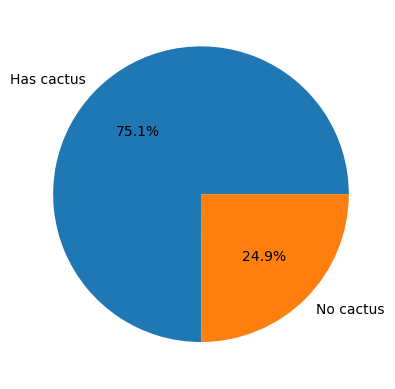

In [14]:
label = ['Has cactus', 'No cactus']
plt.pie(labels['has_cactus'].value_counts(), labels=label, autopct='%.1f%%');
plt.show()


## Extract images

In [15]:
from zipfile import ZipFile

with ZipFile(data_path + 'train.zip') as zipper:
    zipper.extractall()

with ZipFile(data_path + 'test.zip') as zipper:
    zipper.extractall()


In [16]:
# number of images
num_train = len(os.listdir('train/'))
num_test = len(os.listdir('test/'))

print(f'num_train: {num_train}')
print(f'num_test: {num_test}')

num_train: 17500
num_test: 4000


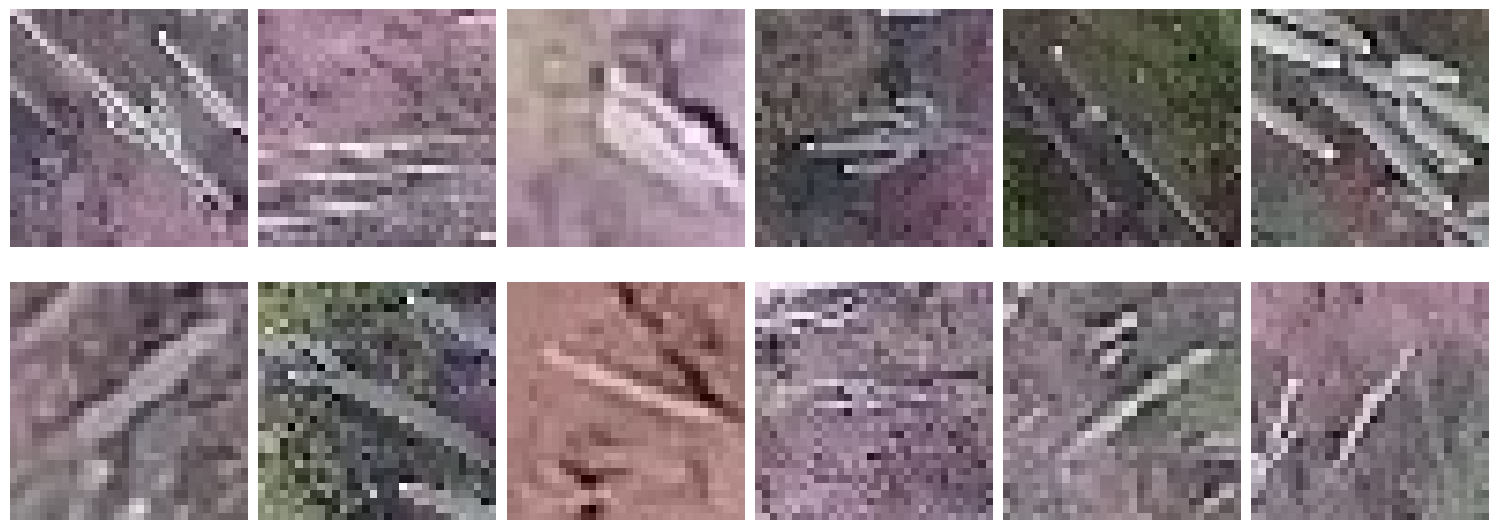

In [11]:
import matplotlib.gridspec as gridspec
import cv2 # opencv

mpl.rc('font', size=7)
fig = plt.figure(figsize=(15, 6))
grid = gridspec.GridSpec(2, 6)

# last 12 images with cactus
last_has_cactus_img_name = labels[labels['has_cactus']==1]['id'][-12:]

# print 12 cautus images
for idx, img_name in enumerate(last_has_cactus_img_name):
    img_path = f"train/{img_name}" 
    image = cv2.imread(img_path)

    if image is None:
        print("Could not read:", img_path)
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # color channel correction
    ax = fig.add_subplot(grid[idx])
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()


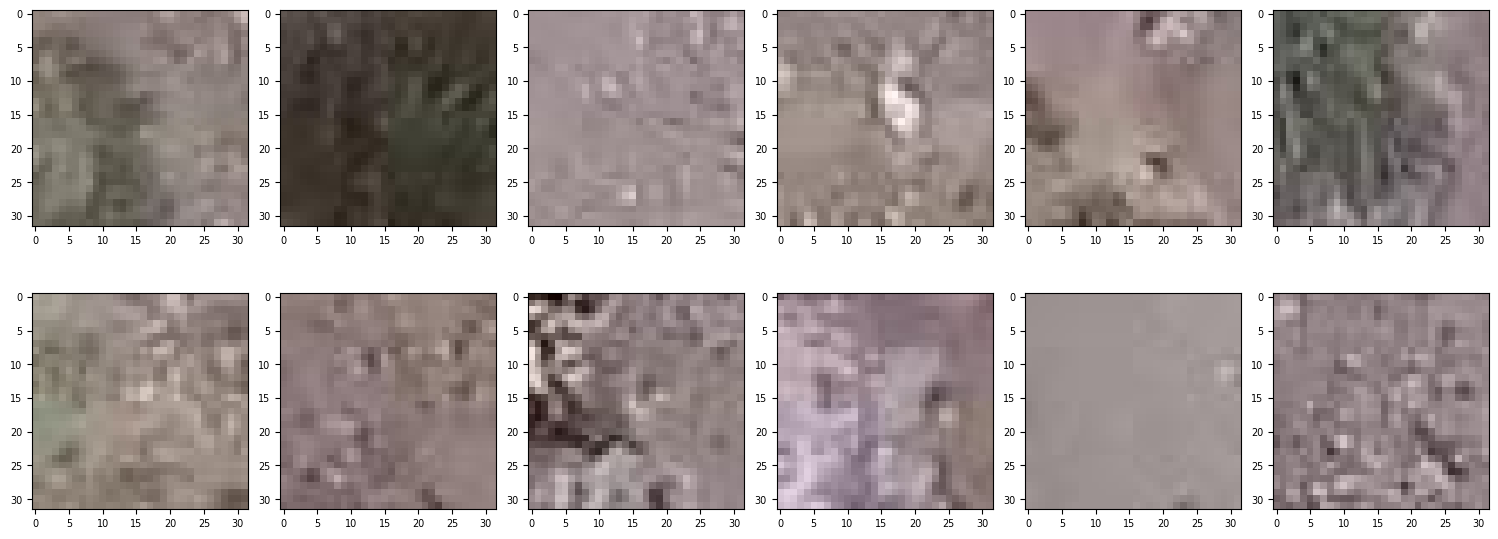

In [14]:
# Images without cactus

plt.figure(figsize=(15, 6))    
grid = gridspec.GridSpec(2, 6) 
    
last_hasnt_cactus_img_name = labels[labels['has_cactus']==0]['id'][-12:]

for idx, img_name in enumerate(last_hasnt_cactus_img_name):
    img_path = 'train/' + img_name                 
    image = cv2.imread(img_path)                   
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
    ax = plt.subplot(grid[idx])
    ax.imshow(image)      

plt.tight_layout()
plt.show()

In [ ]:
# image is 32x32 pixel & 3 colors
image.shape

(32, 32, 3)

# 2. Baseline Strategy

Baseline: 
- Shallow CNN (2 conv layer, pooling layer, flattening layer, fully connected)
- Optimizer: SGD

Improvement: 
- Slightly deeper CNN with batch normalization (5 conv, pooling, flattening, connected)
- Optimizer: adamax
- training epoch up


Using pytorch:
- fix seed, gpu setup
- prep data (train/test, class definition, create dataset, data loader gen)
- Model (CNN)
- Model train (loss, optimizer)
- Eval
- Pred and submit

In [ ]:
import torch, random, os
import numpy as np

# Seed fixing
seed = 50
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
torch.manual_seed(seed)         # using CPU
torch.cuda.manual_seed(seed)    # using GPU
torch.cuda.manual_seed_all(seed) # multi GPU

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

In [ ]:
# Setting up GPU

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Preparing dataset

In [10]:
import pandas as pd

data_path = '/Users/eskoh/Documents/Projects/kaggle/kaggle-cactus-identification/data/'
labels = pd.read_csv(data_path + 'train.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')
